## State Management: Schema + Reducers

The State schema serves as the input schema for all Nodes and Edges in the graph. Let's build an langgraph workflow to understand this.

Let's create a sample schema using TypedDict.

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph
class SummaryState(TypedDict):
    user_name: str
    user_input: str
    summary: str


For more specific value constraints, you can use things like the `Literal` type hint.

In [10]:
from typing import Literal
from langgraph.graph import StateGraph, END
class SummaryState(TypedDict):
    user_name: Literal["Ajay","Vijay"]
    user_input:str
    summary: str

In [19]:
# ------------------------------
# Define Node Functions
# ------------------------------
def summarize_function(state: SummaryState):
    """Simple summarization logic (mock for demo)"""
    text = state.get("user_input", "")
    summary = text[:50] + ("..." if len(text) > 50 else "")
    return {"summary": summary}


In [20]:
# ------------------------------
# Create the Graph
# ------------------------------

In [21]:
from langgraph.graph import StateGraph
graph = StateGraph(SummaryState)
graph.add_node("summarize", summarize_function)
# Define start and end points
graph.set_entry_point("summarize")
graph.add_edge("summarize", END)

In [22]:
# ------------------------------
# Compile the graph
# ------------------------------
app = graph.compile()

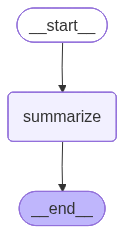

In [23]:
app

In [25]:
# ------------------------------
# Run the graph
# ------------------------------
input_state = {"user_input": "LangGraph enables you to build modular, stateful workflows for AI applications.LangChain is stateless but provides lots of integrations for building LLM powered applications","user_name":"Ajay"}
output_state = app.invoke(input_state)
print("Output State:", output_state)

Output State: {'user_name': 'Ajay', 'user_input': 'LangGraph enables you to build modular, stateful workflows for AI applications.LangChain is stateless but provides lots of integrations for building LLM powered applications', 'summary': 'LangGraph enables you to build modular, stateful w...'}


## Reducers

Control how node outputs update the state.

Example use cases:

    Merging a new message into a conversation history
    
    Aggregating results from multiple agents



### Without a Reducer (The Overwrite Problem)
The default behavior when updating the state is overwrite. Any new value returned for a state field replaces the old value completely.

In [27]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, END

# State Definition (No Reducer)
class NoReducerState(TypedDict):
    """The 'log' field will be overwritten by default."""
    log: List[str]



In [28]:
# Node Functions (Both return a new list)
def node_1(state: NoReducerState) -> NoReducerState:
    log_entry = "Node 1 contribution."
    print(f"-> Node 1 runs. State returned: {log_entry}")
    # Returns a list containing its single contribution
    return {"log": [log_entry]} 

def node_2(state: NoReducerState) -> NoReducerState:
    # State['log'] here is ['Node 1 contribution.']
    log_entry = "Node 2 contribution."
    print(f"-> Node 2 runs. State returned: {log_entry}")
    # Returns a new list containing its single contribution
    return {"log": [log_entry]}



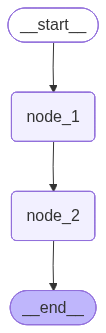

In [29]:
# Build and Run Graph
workflow_no_reducer = StateGraph(NoReducerState)
workflow_no_reducer.add_node("node_1", node_1)
workflow_no_reducer.add_node("node_2", node_2)
workflow_no_reducer.set_entry_point("node_1")
workflow_no_reducer.add_edge("node_1", "node_2")
workflow_no_reducer.add_edge("node_2", END)
app_no_reducer = workflow_no_reducer.compile()
app_no_reducer


In [31]:
result_no_reducer = app_no_reducer.invoke({})

print("\n--- Final State (WITHOUT Reducer) ---")
print(f"Log: {result_no_reducer['log']}")

-> Node 1 runs. State returned: Node 1 contribution.
-> Node 2 runs. State returned: Node 2 contribution.

--- Final State (WITHOUT Reducer) ---
Log: ['Node 2 contribution.']


### With a Reducer (The Append Solution)

By using the `operator.add` reducer, LangGraph combines the new list with the existing list instead of replacing it.

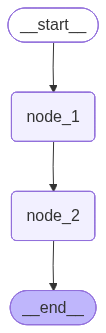

In [32]:
from typing import TypedDict, List, Annotated
import operator
from langgraph.graph import StateGraph, END

# State Definition (With Reducer)
class WithReducerState(TypedDict):
    """The 'log' field is annotated with operator.add to APPEND lists."""
    log: Annotated[List[str], operator.add]

# Node Functions (Identical logic, different state definition)
def node_1_with_reducer(state: WithReducerState) -> WithReducerState:
    log_entry = "Node 1 contribution."
    print(f"-> Node 1 runs. State returned: {log_entry}")
    # Returns a list containing its single contribution
    return {"log": [log_entry]}

def node_2_with_reducer(state: WithReducerState) -> WithReducerState:
    # State['log'] here is ['Node 1 contribution.']
    log_entry = "Node 2 contribution."
    print(f"-> Node 2 runs. State returned: {log_entry}")
    # Returns a new list containing its single contribution
    return {"log": [log_entry]}

# Build and Run Graph
workflow_with_reducer = StateGraph(WithReducerState)
workflow_with_reducer.add_node("node_1", node_1_with_reducer)
workflow_with_reducer.add_node("node_2", node_2_with_reducer)
workflow_with_reducer.set_entry_point("node_1")
workflow_with_reducer.add_edge("node_1", "node_2")
workflow_with_reducer.add_edge("node_2", END)
app_with_reducer = workflow_with_reducer.compile()

app_with_reducer

In [33]:
result_with_reducer = app_with_reducer.invoke({})

print("\n--- Final State (WITH Reducer) ---")
print(f"Log: {result_with_reducer['log']}")

-> Node 1 runs. State returned: Node 1 contribution.
-> Node 2 runs. State returned: Node 2 contribution.

--- Final State (WITH Reducer) ---
Log: ['Node 1 contribution.', 'Node 2 contribution.']


## With Messages 

### MessagesState

The `MessagesState` is a **predefined state class** used to manage the flow of messages between nodes (agents or tools) in the graph.


`MessagesState` is a **default state type** provided by LangGraph that:
- An alternate to `messages: Annotated[List[BaseMessage],add_messages]`
- **Stores messages** exchanged between nodes in the graph.
- Keeps track of the **conversation history** or **intermediate outputs**.
- Is typically used when building **chat-like applications** or **multi-step workflows** where each node contributes to a growing list of messages.

#### Example Usage

When you define a graph like this:

```python
from langgraph.graph import MessagesState, StateGraph

# Create a graph with MessagesState
graph = StateGraph(MessagesState)
```

This means LangGraph:
- "Use a state that tracks messages."
- Each node in the graph will receive the current list of messages and can append new ones.

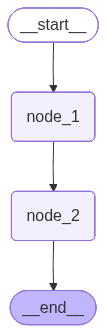

In [4]:
from typing import TypedDict, List, Annotated
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, END, MessagesState
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
import operator


# State Definition (with Reducer) ---
# We use 'add_messages' (preferred) or 'operator.add' to append messages.
class GraphState(TypedDict):
    """The 'messages' field is annotated with the dedicated add_messages reducer."""
    messages: Annotated[List[BaseMessage],add_messages]

# Node Functions ---
def node_1(state: MessagesState) -> GraphState:
    """Adds the user's initial message."""
    user_msg = HumanMessage(content="What are the current flight prices to London?")
    print(f"-> Node 1 runs. Added: HumanMessage")
    # Return the new message as a list
    return {"messages": [user_msg]}

def node_2(state: MessagesState) -> GraphState:
    """Adds the AI's response message."""
    # The reducer ensures that the HumanMessage from node_1 is still in the state
    ai_msg = AIMessage(content="I'll search for flights now. One moment.")
    print(f"-> Node 2 runs. Added: AIMessage")
    # Return the new message as a list
    return {"messages": [ai_msg]}

# Build and Run Graph ---
workflow = StateGraph(MessagesState)
workflow.add_node("node_1", node_1)
workflow.add_node("node_2", node_2)

# Set the flow: node_1 -> node_2 -> END
workflow.set_entry_point("node_1")
workflow.add_edge("node_1", "node_2")
workflow.add_edge("node_2", END)

app = workflow.compile()
workflow.compile()



In [5]:
# Invoke the graph with an empty initial state
result = app.invoke({})



-> Node 1 runs. Added: HumanMessage
-> Node 2 runs. Added: AIMessage


In [6]:
result

{'messages': [HumanMessage(content='What are the current flight prices to London?', additional_kwargs={}, response_metadata={}, id='c408cd78-8671-4179-ac68-ca76093d8785'),
  AIMessage(content="I'll search for flights now. One moment.", additional_kwargs={}, response_metadata={}, id='cd01e3b2-c6b5-486a-8a70-2626ff1945a1', tool_calls=[], invalid_tool_calls=[])]}

In [7]:
# Final Output Inspection ---
print("\n--- Final State (WITH add_messages Reducer) ---")
print(f"Total Messages: {len(result['messages'])}")

print("Message History:")
for i, message in enumerate(result['messages']):
    print(f"  [{i+1}] {type(message).__name__}: {message.content}")


--- Final State (WITH add_messages Reducer) ---
Total Messages: 2
Message History:
  [1] HumanMessage: What are the current flight prices to London?
  [2] AIMessage: I'll search for flights now. One moment.
